# MMHS150K — Phase 0: Data Validation & EDA

This notebook covers everything you need to do after the OCR extraction finishes:

1. **Check OCR progress** — how many images are done
2. **Regenerate VLM data** with real OCR text
3. **Validate the consolidated OCR JSON**
4. **Test the `MMHS150KDataset` PyTorch class**
5. **EDA: Label distributions** — class imbalance
6. **EDA: OCR text analysis** — coverage, length, word freq
7. **EDA: Image metadata** — sizes, corrupt images

> Run cells in order. Each section states its prerequisites.

In [9]:
# ── Bootstrap: add project root to path ──────────────────────────────────────
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent  # notebooks/ -> project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Common paths used throughout this notebook
IMG_DIR      = PROJECT_ROOT / "dataset" / "img_resized"
OCR_OLD_DIR  = PROJECT_ROOT / "dataset" / "img_txt"
OCR_NEW_DIR  = PROJECT_ROOT / "dataset" / "img_txt_new"
OCR_CONSOL   = PROJECT_ROOT / "dataset" / "ocr_consolidated.json"
OCR_FAILURES = PROJECT_ROOT / "dataset" / "ocr_failures.txt"
RESULTS_DIR  = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Python:      ", sys.version[:10])

Project root: C:\Users\ekans\Desktop\Btech\Sem-4\DL\EndSem_Project
Python:       3.12.11 (m


---
## Section 1 — Check Current OCR Extraction Progress

**What is OCR?** OCR stands for **Optical Character Recognition** — software that reads text embedded inside images (e.g. bold text on a meme, text in a protest photo, overlaid captions on screenshots).

**Why are we re-extracting OCR?**

The dataset ships with `dataset/img_txt/` which has old OCR, but:

| Problem | Detail |
|---------|--------|
| **Coverage** | Only **59,252 / 150,000 images** have old OCR (~39.5%). The other 90K have zero text extracted. |
| **Quality** | Old OCR is garbled: `"İ'M SLOWLY BEC«MİNG RETARpEp!"` instead of `"I'M SLOWLY BECOMING RETARDED"` |
| **Age** | Old tools circa 2018, modern EasyOCR/PaddleOCR are dramatically better on meme/stylized text |

The script `scripts/preprocess_ocr.py` runs **EasyOCR with your GTX 1650 GPU** saving results to `dataset/img_txt_new/` (one JSON per image), then consolidates everything into `dataset/ocr_consolidated.json`.

In [10]:
import numpy as np

# ── Count completed OCR files ─────────────────────────────────────────────────
total_images = len(list(IMG_DIR.glob("*.jpg")))
done_files   = list(OCR_NEW_DIR.glob("*.json")) if OCR_NEW_DIR.exists() else []
done_count   = len(done_files)
remaining    = total_images - done_count
pct          = done_count / total_images * 100 if total_images else 0

print("=" * 55)
print("  OCR EXTRACTION PROGRESS")
print("=" * 55)
print(f"  Total images   : {total_images:,}")
print(f"  Completed      : {done_count:,}  ({pct:.1f}%)")
print(f"  Remaining      : {remaining:,}")
print(f"  Consolidated   : {'✅ EXISTS' if OCR_CONSOL.exists() else '⏳ not yet created'}")

failure_count = 0
if OCR_FAILURES.exists():
    failures = OCR_FAILURES.read_text().strip().splitlines()
    failure_count = len(failures)
print(f"  Failed images  : {failure_count}")

# Estimate ETA
if done_count > 0 and remaining > 0:
    speed_its = 1.5  # conservative ~1.5 it/s on GTX 1650
    eta_hours = remaining / speed_its / 3600
    print(f"\n  ETA @ 1.5 it/s : ~{eta_hours:.1f} hours")

if OCR_CONSOL.exists():
    import json
    with open(OCR_CONSOL, encoding="utf-8") as f:
        consol = json.load(f)
    non_empty = sum(1 for v in consol.values() if v.strip())
    print(f"\n  ocr_consolidated.json loaded:")
    print(f"    Total entries : {len(consol):,}")
    print(f"    Non-empty OCR : {non_empty:,} ({non_empty/len(consol)*100:.1f}%)")
    print(f"    Empty (no text in image): {len(consol)-non_empty:,}")
else:
    print("\n  ℹ️  ocr_consolidated.json does not exist yet.")
    print("     It will be created automatically when preprocess_ocr.py finishes.")

  OCR EXTRACTION PROGRESS
  Total images   : 150,000
  Completed      : 150,000  (100.0%)
  Remaining      : 0
  Consolidated   : ✅ EXISTS
  Failed images  : 0

  ocr_consolidated.json loaded:
    Total entries : 146,913
    Non-empty OCR : 80,683 (54.9%)
    Empty (no text in image): 66,230


---
## Section 2 — Regenerate VLM Data with OCR Enrichment

The VLM training files (`dataset/vlm_*.jsonl`) were generated earlier **without OCR text** because extraction was still running. Once OCR finishes, regenerate them so prompts include `Text visible in image: "..."`.

**Before** (no OCR):
```
<image>
Tweet: "[USER] When you're slowly becoming retarded [URL]"

Analyze this tweet and associated image for hate speech...
```

**After** (with OCR):
```
<image>
Tweet: "[USER] When you're slowly becoming retarded [URL]"
Text visible in image: "I'M SLOWLY BECOMING RETARDED"

Analyze this tweet and associated image for hate speech...
```

> **Prerequisite**: `dataset/ocr_consolidated.json` must exist (Section 1 shows ✅).

In [11]:
import subprocess, json

if not OCR_CONSOL.exists():
    print("⚠️  ocr_consolidated.json not found — OCR extraction still running.")
    print("    Come back after Section 1 reports ✅ EXISTS.")
else:
    print("✅ ocr_consolidated.json found — regenerating VLM data...")
    for mode in ["binary", "multiclass"]:
        result = subprocess.run(
            [sys.executable,
             str(PROJECT_ROOT / "scripts" / "generate_vlm_data.py"),
             "--mode", mode, "--ocr-source", "new"],
            capture_output=True, text=True, cwd=str(PROJECT_ROOT),
        )
        print(result.stdout.strip())
        if result.returncode != 0:
            print("❌ Error:", result.stderr[:400])

    # Spot-check: find a sample that has OCR text in its prompt
    sample_path = PROJECT_ROOT / "dataset" / "vlm_val_binary.jsonl"
    with open(sample_path, encoding="utf-8") as f:
        for line in f:
            s = json.loads(line)
            prompt = s["conversations"][0]["value"]
            if "Text visible" in prompt:
                print("\n--- Sample prompt with OCR enriched ---")
                print(prompt[:400])
                print("Answer:", s["conversations"][1]["value"])
                break
        else:
            print("\n(No samples with OCR text found — images may not have detectable text)")

✅ ocr_consolidated.json found — regenerating VLM data...
[INFO] Saved 134823 samples â†’ C:\Users\ekans\Desktop\Btech\Sem-4\DL\EndSem_Project\dataset\vlm_train_binary.jsonl
[INFO] Saved 5000 samples â†’ C:\Users\ekans\Desktop\Btech\Sem-4\DL\EndSem_Project\dataset\vlm_val_binary.jsonl
[INFO] Saved 10000 samples â†’ C:\Users\ekans\Desktop\Btech\Sem-4\DL\EndSem_Project\dataset\vlm_test_binary.jsonl
[INFO] Saved 134823 samples â†’ C:\Users\ekans\Desktop\Btech\Sem-4\DL\EndSem_Project\dataset\vlm_train_multiclass.jsonl
[INFO] Saved 5000 samples â†’ C:\Users\ekans\Desktop\Btech\Sem-4\DL\EndSem_Project\dataset\vlm_val_multiclass.jsonl
[INFO] Saved 10000 samples â†’ C:\Users\ekans\Desktop\Btech\Sem-4\DL\EndSem_Project\dataset\vlm_test_multiclass.jsonl

--- Sample prompt with OCR enriched ---
<image>
Tweet: "fuck my pussy chaturbate cut fingering happy tugs hot cunt tyra misoux switzerland [URL]"
Text visible in image: "THEASSPACTOR"

Analyze this tweet and associated image for hate speech. Cons

---
## Section 3 — Validate Consolidated OCR JSON

Before using new OCR for training, confirm the data is clean: no nulls, no corrupt entries, text lengths are reasonable.

In [13]:
import json, random
import numpy as np

if not OCR_CONSOL.exists():
    print("⚠️  ocr_consolidated.json not found — skip this section for now.")
else:
    with open(OCR_CONSOL, encoding="utf-8") as f:
        ocr_data = json.load(f)

    total      = len(ocr_data)
    empty_ids  = [k for k, v in ocr_data.items() if not v or not v.strip()]
    non_empty  = total - len(empty_ids)
    lengths    = [len(v.strip()) for v in ocr_data.values() if v and v.strip()]

    print(f"{'='*50}")
    print(f"  Consolidated OCR JSON Validation")
    print(f"{'='*50}")
    print(f"  Total entries       : {total:,}")
    print(f"  Non-empty OCR text  : {non_empty:,}  ({non_empty/total*100:.1f}%)")
    print(f"  Empty (no text)     : {len(empty_ids):,}  ({len(empty_ids)/total*100:.1f}%)")
    print(f"\n  Text length stats (non-empty):")
    print(f"    Min    : {min(lengths)} chars")
    print(f"    Median : {np.median(lengths):.0f} chars")
    print(f"    Mean   : {np.mean(lengths):.1f} chars")
    print(f"    p95    : {np.percentile(lengths, 95):.0f} chars")
    print(f"    Max    : {max(lengths)} chars")

    # Null / whitespace-only check
    null_ids = [k for k, v in ocr_data.items() if v is None]
    print(f"\n  Null values         : {len(null_ids)}")
    print(f"  ✅ Validation passed" if not null_ids else f"  ⚠️ Found {len(null_ids)} null values!")

    random.seed(42)
    sample_ids = random.sample([k for k in ocr_data if ocr_data[k].strip()], 5)
    print("\n  Random samples:")
    for tid in sample_ids:
        print(f"    {tid}: {ocr_data[tid][:80]!r}")

  Consolidated OCR JSON Validation
  Total entries       : 146,913
  Non-empty OCR text  : 80,683  (54.9%)
  Empty (no text)     : 66,230  (45.1%)

  Text length stats (non-empty):
    Min    : 1 chars
    Median : 21 chars
    Mean   : 61.7 chars
    p95    : 267 chars
    Max    : 2297 chars

  Null values         : 0
  ✅ Validation passed

  Random samples:
    1055098798169501696: 'CANCEL THAT'
    1037073427436371969: 'YOU ARE SO DUMB.'
    1106895156807110658: 'Snoop Dogg feat.The Doors Fiders on theStorm (FredareckRem) NeedorSpeedUndergu2E'
    1105632710121439232: 'THII TRUMP CAN GRAB MY'
    1105220316312285185: 'May arrives in Strasbourg for Brexit talks'


---
## Section 4 — Test `MMHS150KDataset` Class

The PyTorch Dataset used during training. We verify length, sample dict structure, tensor shapes, and DataLoader batching.

> Use `ocr_source="new"` once `ocr_consolidated.json` exists (fast, single-file load).  
> `ocr_source="old"` works now but takes 5+ minutes (reads 59K individual files).

In [14]:
import time
import torch
from torch.utils.data import DataLoader
from src.data.dataset import MMHS150KDataset, mmhs_collate_fn

# Choose OCR source
ocr_src = "new" if OCR_CONSOL.exists() else "old"
if ocr_src == "old":
    print("⚠️  Using 'old' OCR (may take 5+ min to load). Wait for OCR extraction and use 'new'.")
else:
    print(f"Using OCR source: '{ocr_src}'")

# ── Load val split (5,000 samples — fastest to test) ─────────────────────────
print("\nLoading val split (5,000 samples)...")
t0  = time.time()
ds  = MMHS150KDataset(split="val", ocr_source=ocr_src)
print(f"Loaded in {time.time()-t0:.1f}s")

# ── Length check ──────────────────────────────────────────────────────────────
print(f"\nlen(dataset) = {len(ds)}")
assert len(ds) == 5000, f"Expected 5000, got {len(ds)}"
print("✅ Length correct (5,000)")

# ── Single item check ─────────────────────────────────────────────────────────
sample = ds[0]
print("\nSample keys :", list(sample.keys()))
print("image shape :", sample["image"].shape)         # (3, 224, 224)
print("image dtype :", sample["image"].dtype)
print("tweet_text  :", sample["tweet_text"][:80])
print("ocr_text    :", (sample["ocr_text"][:60] if sample["ocr_text"] else "(empty — no image text)"))
print("label       :", sample["label"], " (6-class, 0=NotHate … 5=OtherHate)")
print("label_binary:", sample["label_binary"], " (0=NotHate, 1=Hate)")
print("soft_label  :", sample["soft_label"].tolist())
print("tweet_id    :", sample["tweet_id"])
print("agreement   :", sample["agreement_level"], " (3=unanimous, 2=majority, 1=all disagree)")

# Assertions
assert sample["image"].shape == (3, 224, 224)
assert sample["image"].dtype == torch.float32
assert sample["label"] in range(6)
assert sample["label_binary"] in (0, 1)
assert sample["soft_label"].shape == (6,)
assert abs(sample["soft_label"].sum().item() - 1.0) < 1e-5, "Soft labels must sum to 1.0"
print("\n✅ All single-item assertions passed")

Using OCR source: 'new'

Loading val split (5,000 samples)...
Loaded in 0.0s

len(dataset) = 5000
✅ Length correct (5,000)

Sample keys : ['image', 'tweet_text', 'ocr_text', 'label', 'label_binary', 'soft_label', 'tweet_id', 'agreement_level']
image shape : torch.Size([3, 224, 224])
image dtype : torch.float32
tweet_text  : fuck my pussy chaturbate cut fingering happy tugs hot cunt tyra misoux switzerla
ocr_text    : THEASSPACTOR
label       : 2  (6-class, 0=NotHate … 5=OtherHate)
label_binary: 1  (0=NotHate, 1=Hate)
soft_label  : [0.3333333432674408, 0.0, 0.6666666865348816, 0.0, 0.0, 0.0]
tweet_id    : 1062433411107713025
agreement   : 2  (3=unanimous, 2=majority, 1=all disagree)

✅ All single-item assertions passed


---
## Section 5 — EDA: Label Distributions

Understand the class imbalance across both the **6-class** (NotHate, Racist, Sexist, Homophobe, Religion, OtherHate) and **binary** (NotHate vs. Hate) tasks.

The label for each sample is derived from the **majority vote** of three annotators.  
A sample is **binary-hate** if the majority vote label ≠ 0 (NotHate).

| Label ID | Name       |
|----------|------------|
| 0        | NotHate    |
| 1        | Racist     |
| 2        | Sexist     |
| 3        | Homophobe  |
| 4        | Religion   |
| 5        | OtherHate  |

> **No prerequisites.** Reads `dataset/MMHS150K_GT.json` directly.

  6-CLASS LABEL DISTRIBUTION (majority vote)
  0 NotHate      : 116,790  ( 78.0%)  ██████████████████████████████████████
  1 Racist       : 14,183  (  9.5%)  ████
  2 Sexist       :  5,375  (  3.6%)  █
  3 Homophobe    :  4,926  (  3.3%)  █
  4 Religion     :    353  (  0.2%)  
  5 OtherHate    :  8,196  (  5.5%)  ██

  Total samples: 149,823

  BINARY LABEL DISTRIBUTION (NotHate vs. Hate)
  0 NotHate  : 116,790  ( 78.0%)
  1 Hate     : 33,033  ( 22.0%)

  ANNOTATOR AGREEMENT
  Unanimous (3/3)                 : 62,025  (41.4%)
  Majority (2/3)                  : 76,097  (50.8%)
  All disagree (3 diff labels)    : 11,701  (7.8%)


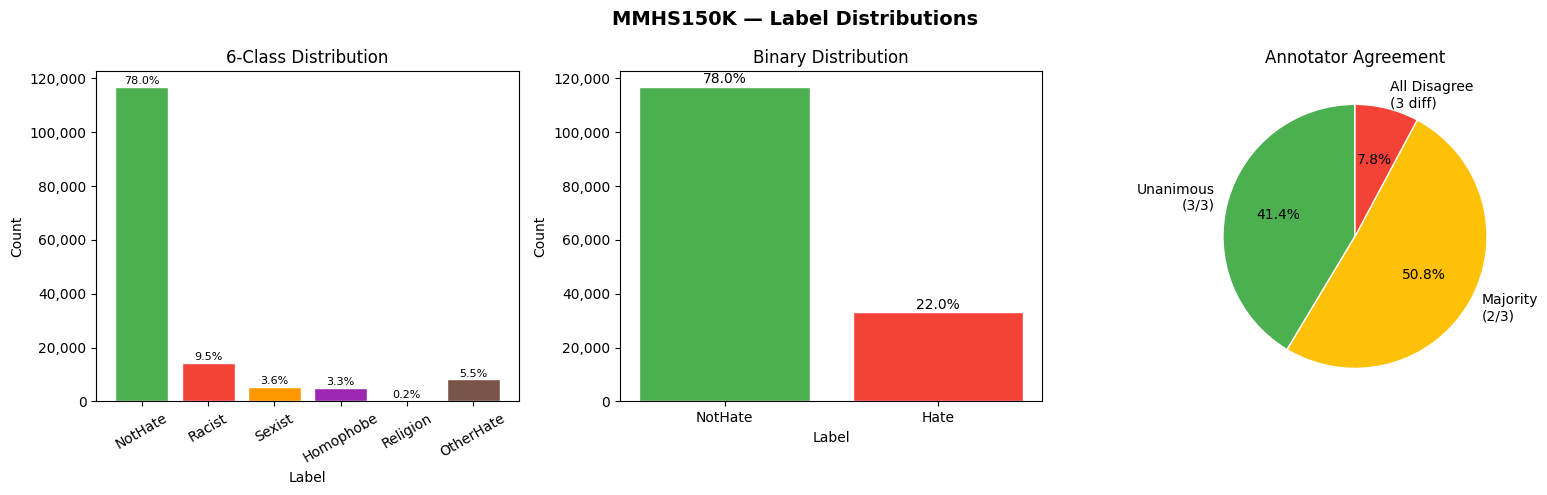

Plot saved to results/label_distributions.png


In [15]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
GT_FILE = PROJECT_ROOT / "dataset" / "MMHS150K_GT.json"

with open(GT_FILE, encoding="utf-8") as f:
    gt = json.load(f)

LABEL_NAMES = ["NotHate", "Racist", "Sexist", "Homophobe", "Religion", "OtherHate"]

# ── Majority-vote label per sample ───────────────────────────────────────────
def majority_vote(labels: list) -> int:
    """Return mode; ties broken by lowest label id."""
    cnt = Counter(labels)
    return cnt.most_common(1)[0][0]

majority_labels = [majority_vote(v["labels"]) for v in gt.values()]
binary_labels   = [0 if lbl == 0 else 1 for lbl in majority_labels]

six_class_counts = Counter(majority_labels)
binary_counts    = Counter(binary_labels)

print("=" * 50)
print("  6-CLASS LABEL DISTRIBUTION (majority vote)")
print("=" * 50)
total = len(majority_labels)
for lbl_id, name in enumerate(LABEL_NAMES):
    cnt = six_class_counts.get(lbl_id, 0)
    bar = "█" * int(cnt / total * 50)
    print(f"  {lbl_id} {name:<12} : {cnt:6,}  ({cnt/total*100:5.1f}%)  {bar}")

print(f"\n  Total samples: {total:,}")

print("\n" + "=" * 50)
print("  BINARY LABEL DISTRIBUTION (NotHate vs. Hate)")
print("=" * 50)
for lbl_id, name in enumerate(["NotHate", "Hate"]):
    cnt = binary_counts[lbl_id]
    print(f"  {lbl_id} {name:<8} : {cnt:6,}  ({cnt/total*100:5.1f}%)")

# ── Annotator agreement ────────────────────────────────────────────────────────
agreement_levels = []
for v in gt.values():
    lbls = v["labels"]
    unique_count = len(set(lbls))
    if unique_count == 1:
        agreement_levels.append(3)  # unanimous
    elif unique_count == 2:
        agreement_levels.append(2)  # 2-1 majority
    else:
        agreement_levels.append(1)  # all disagree (no majority)

agree_cnt = Counter(agreement_levels)
print("\n" + "=" * 50)
print("  ANNOTATOR AGREEMENT")
print("=" * 50)
labels_agree = {3: "Unanimous (3/3)", 2: "Majority (2/3)", 1: "All disagree (3 diff labels)"}
for k in sorted(agree_cnt.keys(), reverse=True):
    cnt = agree_cnt[k]
    print(f"  {labels_agree[k]:<32}: {cnt:6,}  ({cnt/total*100:.1f}%)")

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("MMHS150K — Label Distributions", fontsize=14, fontweight="bold")

# 6-class bar chart
ax1 = axes[0]
counts_6 = [six_class_counts.get(i, 0) for i in range(6)]
colors_6  = ["#4CAF50", "#F44336", "#FF9800", "#9C27B0", "#2196F3", "#795548"]
bars = ax1.bar(LABEL_NAMES, counts_6, color=colors_6, edgecolor="white")
ax1.set_title("6-Class Distribution")
ax1.set_xlabel("Label")
ax1.set_ylabel("Count")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.tick_params(axis="x", rotation=30)
for bar, cnt in zip(bars, counts_6):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
             f"{cnt/total*100:.1f}%", ha="center", va="bottom", fontsize=8)

# Binary bar chart
ax2 = axes[1]
counts_bin = [binary_counts[0], binary_counts[1]]
bars2 = ax2.bar(["NotHate", "Hate"], counts_bin, color=["#4CAF50", "#F44336"], edgecolor="white")
ax2.set_title("Binary Distribution")
ax2.set_xlabel("Label")
ax2.set_ylabel("Count")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, cnt in zip(bars2, counts_bin):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
             f"{cnt/total*100:.1f}%", ha="center", va="bottom", fontsize=10)

# Agreement pie chart
ax3 = axes[2]
sizes  = [agree_cnt[k] for k in [3, 2, 1]]
labels_pie = ["Unanimous\n(3/3)", "Majority\n(2/3)", "All Disagree\n(3 diff)"]
ax3.pie(sizes, labels=labels_pie, autopct="%1.1f%%",
        colors=["#4CAF50", "#FFC107", "#F44336"], startangle=90,
        wedgeprops={"edgecolor": "white"})
ax3.set_title("Annotator Agreement")

plt.tight_layout()
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)
plt.savefig(results_dir / "label_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to results/label_distributions.png")


---
## Section 6 — EDA: OCR Text Analysis

Analyse how much text is embedded in the images and its quality:

- **Coverage**: what fraction of images contain any detected text
- **Text length distribution**: histogram of character counts
- **Word frequency**: top-50 most common words in image OCR text
- **Confidence distribution**: quality of the OCR detections

If `ocr_consolidated.json` does not exist yet (OCR is still running), this section will show statistics on the **old OCR** from `dataset/img_txt/` as a baseline, and a reminder to re-run once new OCR finishes.

> **Prerequisite**: At minimum the old `dataset/img_txt/` folder must exist.

Using new OCR (ocr_consolidated.json)
Source     : New OCR (PP-OCRv5)

  OCR COVERAGE
  Total images      : 150,000
  Processed         : 146,913
  With text         : 80,683  (53.8% of total)
  Empty (no text)   : 66,230  (45.1% of processed)

  Text length (chars):
    Min     : 1
    Median  : 21
    Mean    : 61.7
    p75     : 67
    p95     : 267
    Max     : 2297

  Top-20 words in OCR text:
  Word                 Count
  ------------------------------
  com                  5,810
  your                 3,879
  me                   2,831
  my                   2,577
  tweet                2,448
  all                  2,004
  what                 1,938
  no                   1,880
  like                 1,730
  tweets               1,678
  up                   1,528
  pm                   1,457
  ago                  1,417
  more                 1,389
  reply                1,337
  lte                  1,253
  don                  1,245
  now                  1,241
  message    

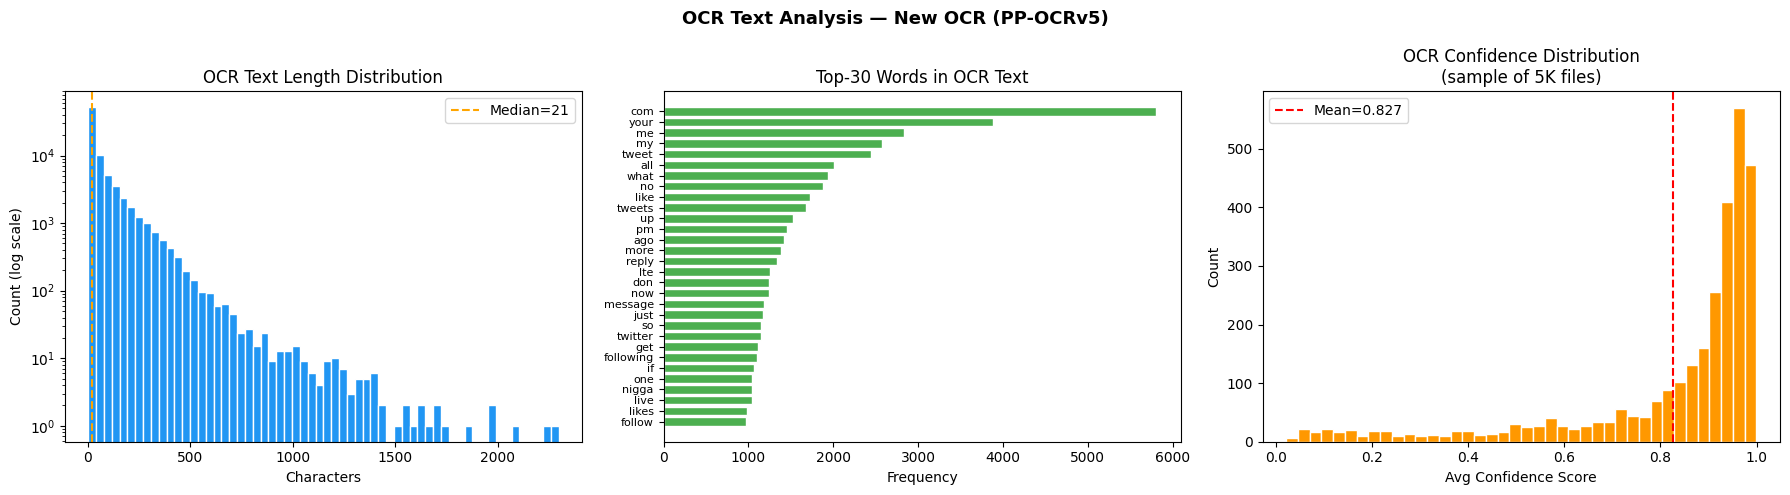

Plot saved to results/ocr_text_analysis.png


In [16]:
import json, re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

PROJECT_ROOT = Path().resolve().parent
OCR_NEW_DIR  = PROJECT_ROOT / "dataset" / "img_txt_new"
OCR_OLD_DIR  = PROJECT_ROOT / "dataset" / "img_txt"
OCR_CONSOL   = PROJECT_ROOT / "dataset" / "ocr_consolidated.json"
GT_FILE      = PROJECT_ROOT / "dataset" / "MMHS150K_GT.json"

total_images = len(list((PROJECT_ROOT / "dataset" / "img_resized").glob("*.jpg")))

# ── Load OCR data ─────────────────────────────────────────────────────────────
using_new = False
if OCR_CONSOL.exists():
    print("Using new OCR (ocr_consolidated.json)")
    using_new = True
    with open(OCR_CONSOL, encoding="utf-8") as f:
        ocr_map = json.load(f)          # {tweet_id: "text"}
    source_label = "New OCR (PP-OCRv5)"
elif OCR_NEW_DIR.exists() and any(OCR_NEW_DIR.glob("*.json")):
    # partial extraction: read completed files
    files = list(OCR_NEW_DIR.glob("*.json"))
    print(f"Using partial new OCR: {len(files):,} files completed so far")
    ocr_map = {}
    for p in files:
        try:
            d = json.loads(p.read_text(encoding="utf-8"))
            ocr_map[p.stem] = d.get("ocr_text", "")
        except Exception:
            pass
    source_label = f"New OCR (partial, {len(ocr_map):,}/{total_images:,})"
else:
    print("⚠️  No new OCR found. Falling back to OLD OCR for baseline stats.")
    files = list(OCR_OLD_DIR.glob("*.json")) if OCR_OLD_DIR.exists() else []
    ocr_map = {}
    for p in files:
        try:
            d = json.loads(p.read_text(encoding="utf-8"))
            ocr_map[p.stem] = " ".join(d.get("img_text", []))
        except Exception:
            pass
    source_label = f"Old OCR (baseline, {len(ocr_map):,}/{total_images:,})"

print(f"Source     : {source_label}")

# ── Coverage stats ────────────────────────────────────────────────────────────
all_texts   = list(ocr_map.values())
non_empty   = [t for t in all_texts if t and t.strip()]
empty       = len(all_texts) - len(non_empty)
coverage    = len(non_empty) / total_images * 100
print(f"\n{'='*55}")
print(f"  OCR COVERAGE")
print(f"{'='*55}")
print(f"  Total images      : {total_images:,}")
print(f"  Processed         : {len(all_texts):,}")
print(f"  With text         : {len(non_empty):,}  ({coverage:.1f}% of total)")
print(f"  Empty (no text)   : {empty:,}  ({empty/len(all_texts)*100:.1f}% of processed)")

# ── Text length distribution ──────────────────────────────────────────────────
lengths = [len(t.strip()) for t in non_empty]
print(f"\n  Text length (chars):")
print(f"    Min     : {min(lengths)}")
print(f"    Median  : {np.median(lengths):.0f}")
print(f"    Mean    : {np.mean(lengths):.1f}")
print(f"    p75     : {np.percentile(lengths, 75):.0f}")
print(f"    p95     : {np.percentile(lengths, 95):.0f}")
print(f"    Max     : {max(lengths)}")

# ── Top words ─────────────────────────────────────────────────────────────────
STOPWORDS = {"the", "a", "an", "and", "or", "but", "is", "are", "was", "were",
             "to", "of", "in", "on", "at", "for", "with", "this", "that", "it",
             "be", "by", "as", "from", "do", "not", "i", "you", "he", "she",
             "we", "they", "have", "has", "had", "will", "would", "can", "could",
             "s", "t", "re", "ve", "ll", "m", "d", "rt", "amp"}
words = []
for text in non_empty:
    toks = re.findall(r"\b[a-zA-Z]{2,}\b", text.lower())
    words.extend(t for t in toks if t not in STOPWORDS)

top50 = Counter(words).most_common(50)
print(f"\n  Top-20 words in OCR text:")
print(f"  {'Word':<20} Count")
print(f"  {'-'*30}")
for word, cnt in top50[:20]:
    print(f"  {word:<20} {cnt:,}")

# ── Confidence distribution (new OCR only) ────────────────────────────────────
confidences = []
if using_new and OCR_CONSOL.exists():
    # Confidence is not stored in consolidated JSON — check img_txt_new if available
    if OCR_NEW_DIR.exists():
        sample_files = list(OCR_NEW_DIR.glob("*.json"))[:5000]
        for p in sample_files:
            try:
                d = json.loads(p.read_text(encoding="utf-8"))
                c = d.get("confidence", None)
                if c is not None and c > 0:
                    confidences.append(c)
            except Exception:
                pass

# ── Plots ─────────────────────────────────────────────────────────────────────
ncols  = 3 if confidences else 2
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
fig.suptitle(f"OCR Text Analysis — {source_label}", fontsize=13, fontweight="bold")

# Text length histogram
ax1 = axes[0]
ax1.hist(lengths, bins=60, color="#2196F3", edgecolor="white", log=True)
ax1.axvline(np.median(lengths), color="orange", linestyle="--", label=f"Median={np.median(lengths):.0f}")
ax1.set_title("OCR Text Length Distribution")
ax1.set_xlabel("Characters")
ax1.set_ylabel("Count (log scale)")
ax1.legend()

# Top-30 words bar chart
ax2 = axes[1]
words30, cnts30 = zip(*top50[:30])
y_pos = range(len(words30))
ax2.barh(y_pos, cnts30, color="#4CAF50", edgecolor="white")
ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(words30, fontsize=8)
ax2.invert_yaxis()
ax2.set_title("Top-30 Words in OCR Text")
ax2.set_xlabel("Frequency")

# Confidence histogram (new OCR only)
if confidences:
    ax3 = axes[2]
    ax3.hist(confidences, bins=40, color="#FF9800", edgecolor="white")
    ax3.axvline(np.mean(confidences), color="red", linestyle="--",
                label=f"Mean={np.mean(confidences):.3f}")
    ax3.set_title("OCR Confidence Distribution\n(sample of 5K files)")
    ax3.set_xlabel("Avg Confidence Score")
    ax3.set_ylabel("Count")
    ax3.legend()

plt.tight_layout()
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)
plt.savefig(results_dir / "ocr_text_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to results/ocr_text_analysis.png")


---
## Section 7 — EDA: Image Metadata

Check the physical properties of the 150K resized images:

- **Size distribution**: width × height (should be ~256×256 after resizing)
- **File size distribution**: bytes on disk
- **Aspect ratio distribution**: portrait vs. landscape vs. square
- **Corrupt image detection**: images that can't be decoded by PIL

> **Prerequisite**: `dataset/img_resized/` must exist (ships with the dataset).  
> This cell samples up to 10,000 images for speed — full scan takes ~10 minutes.

Total images in img_resized: 150,000
Sampling 10,000 images for analysis...

  IMAGE METADATA (sample=10,000)
  Valid images   : 10,000
  Corrupt/broken : 0  (0.00%)

  Width  — min=500  median=503  max=9656
  Height — min=500  median=500  max=3671
  File size — min=5KB  median=39KB  max=221KB  total≈410MB (sample)

  Aspect ratio (width/height):
    Square (0.9–1.1) : 1,776  (17.8%)
    Landscape (>1.1) : 4,608  (46.1%)
    Portrait  (<0.9) : 3,616  (36.2%)


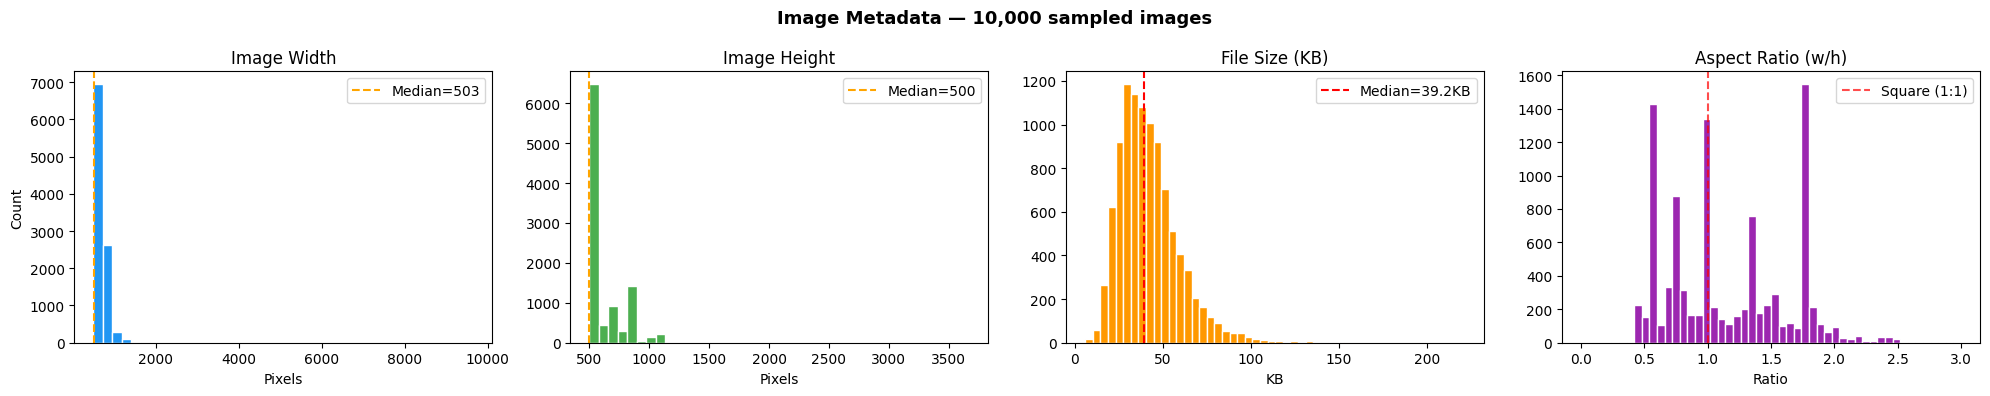

Plot saved to results/image_metadata.png


In [17]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

try:
    from PIL import Image
    PIL_AVAILABLE = True
except ImportError:
    PIL_AVAILABLE = False
    print("⚠️  Pillow not installed. Run: pip install Pillow")

PROJECT_ROOT = Path().resolve().parent
IMG_DIR = PROJECT_ROOT / "dataset" / "img_resized"

all_imgs = sorted(IMG_DIR.glob("*.jpg"))
total    = len(all_imgs)
print(f"Total images in img_resized: {total:,}")

if not PIL_AVAILABLE or total == 0:
    print("⚠️  Skipping image metadata analysis (PIL unavailable or no images found).")
else:
    # Sample up to 10K for speed
    SAMPLE_SIZE = min(10_000, total)
    random.seed(42)
    sample_imgs = random.sample(all_imgs, SAMPLE_SIZE)
    print(f"Sampling {SAMPLE_SIZE:,} images for analysis...")

    widths, heights, file_sizes, aspect_ratios = [], [], [], []
    corrupt_ids = []

    for img_path in sample_imgs:
        fsize = img_path.stat().st_size
        file_sizes.append(fsize)
        try:
            with Image.open(img_path) as im:
                im.verify()          # detect truncated/corrupt files
            with Image.open(img_path) as im:
                w, h = im.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h if h > 0 else 1.0)
        except Exception:
            corrupt_ids.append(img_path.stem)

    valid = len(widths)
    print(f"\n{'='*55}")
    print(f"  IMAGE METADATA (sample={SAMPLE_SIZE:,})")
    print(f"{'='*55}")
    print(f"  Valid images   : {valid:,}")
    print(f"  Corrupt/broken : {len(corrupt_ids):,}  ({len(corrupt_ids)/SAMPLE_SIZE*100:.2f}%)")
    if corrupt_ids:
        print(f"  First 5 corrupt IDs: {corrupt_ids[:5]}")

    print(f"\n  Width  — min={min(widths)}  median={int(np.median(widths))}  max={max(widths)}")
    print(f"  Height — min={min(heights)}  median={int(np.median(heights))}  max={max(heights)}")
    print(f"  File size — min={min(file_sizes)//1024}KB  "
          f"median={int(np.median(file_sizes))//1024}KB  "
          f"max={max(file_sizes)//1024}KB  "
          f"total≈{sum(file_sizes)//1024//1024}MB (sample)")

    # Aspect ratio buckets
    sq  = sum(1 for ar in aspect_ratios if 0.9 <= ar <= 1.1)
    ls  = sum(1 for ar in aspect_ratios if ar > 1.1)
    pt  = sum(1 for ar in aspect_ratios if ar < 0.9)
    print(f"\n  Aspect ratio (width/height):")
    print(f"    Square (0.9–1.1) : {sq:,}  ({sq/valid*100:.1f}%)")
    print(f"    Landscape (>1.1) : {ls:,}  ({ls/valid*100:.1f}%)")
    print(f"    Portrait  (<0.9) : {pt:,}  ({pt/valid*100:.1f}%)")

    # ── Plots ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f"Image Metadata — {SAMPLE_SIZE:,} sampled images", fontsize=13, fontweight="bold")

    # Width distribution
    axes[0].hist(widths, bins=40, color="#2196F3", edgecolor="white")
    axes[0].axvline(np.median(widths), color="orange", linestyle="--",
                    label=f"Median={int(np.median(widths))}")
    axes[0].set_title("Image Width")
    axes[0].set_xlabel("Pixels")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    # Height distribution
    axes[1].hist(heights, bins=40, color="#4CAF50", edgecolor="white")
    axes[1].axvline(np.median(heights), color="orange", linestyle="--",
                    label=f"Median={int(np.median(heights))}")
    axes[1].set_title("Image Height")
    axes[1].set_xlabel("Pixels")
    axes[1].legend()

    # File size distribution (KB)
    fsizes_kb = [s / 1024 for s in file_sizes]
    axes[2].hist(fsizes_kb, bins=50, color="#FF9800", edgecolor="white")
    axes[2].axvline(np.median(fsizes_kb), color="red", linestyle="--",
                    label=f"Median={np.median(fsizes_kb):.1f}KB")
    axes[2].set_title("File Size (KB)")
    axes[2].set_xlabel("KB")
    axes[2].legend()

    # Aspect ratio distribution
    axes[3].hist(aspect_ratios, bins=50, color="#9C27B0", edgecolor="white", range=(0, 3))
    axes[3].axvline(1.0, color="red", linestyle="--", alpha=0.7, label="Square (1:1)")
    axes[3].set_title("Aspect Ratio (w/h)")
    axes[3].set_xlabel("Ratio")
    axes[3].legend()

    plt.tight_layout()
    results_dir = PROJECT_ROOT / "results"
    results_dir.mkdir(exist_ok=True)
    plt.savefig(results_dir / "image_metadata.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved to results/image_metadata.png")
